# Preliminaries

In [2]:
import numpy as np
import numpy.polynomial.polynomial as poly

import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import FormatStrFormatter

import scipy.constants as const
from scipy.signal import fftconvolve, welch
import scipy.optimize as optimize

import pycbc.psd, pycbc.filter, pycbc.noise
from pycbc.types import TimeSeries

plt.rcParams['text.usetex'] = True

#define the solar mass in [kg] and parsec in [meters]
sol = 1.989e30
pc = 3.086e16

/opt/anaconda3/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


# 1: Function Definitions

First, we redefine the waveforms of the quasi-circular binary system and the quasi-circular Lagrange three-body system so that the waveforms are in SI units and are compatible with the `PyCBC` methods. Following also what is common in the literature, the input masses and distances will be in solar masses and in parsecs, respectively.

In [5]:
#for the waveforms of the quasi-circular binary system and quasi-circular Lagrange triple
import waveforms

print(waveforms.CircularBinary.__doc__)
print(waveforms.CircularLagrangeTriple.__doc__)

CircularBinary contains the waveforms for a quasi-circular binary system up to the 0.5-PN approximation.
    Upon initialization, the user must supply the following parameters of the binary:

    l = initial separation distance in [pc],
    m1, m2 = masses of the individual masses in [solar mass],
    r = distance to the binary system in [pc],
    i_deg = orbital inclination angle in [deg],
    phi = integration constant corresponding to the value of the phase at coalescence [rad]
    

    CircularLagrangeTriple contains the waveforms for a quasi-circular Lagrange three-body system up to the 0.5-PN approximation.
    Upon initialization, the user must supply the following parameters of the binary:

    l = initial separation distance in [pc],
    m1, m2, m3 = masses of the individual masses in [solar mass],
    r = distance to the binary system in [pc],
    i_deg = orbital inclination angle in [deg],
    phi = integration constant corresponding to the value of the phase at coalescence

The following functions are for calculating the parameters of the Lagrange triple that give out the same waveform as that of a given binary system.

In [7]:
def findQuadDegeneracy_plus(a, m1_2B, m2_2B, r_2B, i_2B_deg, M_3B, beta_1, i_3B_deg, atol = 1e-23):
    #initialize binary
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B_deg, 0)
    w_2B = np.sqrt(const.G*binary.M/(binary.l**3))
    i_2B = np.radians(i_2B_deg)

    #free parameters of the Lagrange triple
    M_3B *= sol
    i_3B = np.radians(i_3B_deg)

    #parameters to solve
    r_3B = ((M_3B/binary.M_c)**(5/3))*(binary.r*beta_1*np.abs(3*beta_1 - 1)*(1 + (np.cos(i_3B))**2))/(1 + (np.cos(i_2B))**2)
    b = (const.G*M_3B/(w_2B**2))**(1/3)

    #find the appropriate integration constant Phi_c
    phi_3B = 0
    shift = np.linspace(0, 2*np.pi, 1000)
    for phi in shift:
        temp = [b/pc, M_3B*beta_1/sol, M_3B*beta_1/sol, M_3B*(1 - 2*beta_1)/sol, r_3B/pc, i_3B_deg, phi]
        lagrange = waveforms.CircularLagrangeTriple(*temp)
        check = np.abs(binary.h_quad(t_max = 1, radRxn = True, pol = "plus")[:4] - lagrange.h_quad(t_max = 1, radRxn = True, pol = "plus")[:4])
            
        if all(np.isclose(check, 0, atol = atol)):
            phi_3B = phi

    #return b and r_3B in [pc]
    return b/pc, r_3B/pc, phi_3B

def findQuadDegeneracy_cross(a, m1_2B, m2_2B, r_2B, i_2B_deg, M_3B, beta_1, i_3B_deg, atol = 1e-23):
    #initialize binary
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B_deg, 0)
    w_2B = np.sqrt(const.G*binary.M/(binary.l**3))
    i_2B = np.radians(i_2B_deg)

    #free parameters of the Lagrange triple
    M_3B *= sol
    i_3B = np.radians(i_3B_deg)

    #parameters to solve
    r_3B = ((M_3B/binary.M_c)**(5/3))*(binary.r*beta_1*np.abs(3*beta_1 - 1)*np.cos(i_3B))/np.cos(i_2B)
    b = (const.G*M_3B/(w_2B**2))**(1/3)

    #find the appropriate integration constant Phi_c
    phi_3B = 0
    shift = np.linspace(0, 2*np.pi, 1000)
    for phi in shift:
        temp = [b/pc, M_3B*beta_1/sol, M_3B*beta_1/sol, M_3B*(1 - 2*beta_1)/sol, r_3B/pc, i_3B_deg, phi]
        lagrange = waveforms.CircularLagrangeTriple(*temp)
        check = np.abs(binary.h_quad(t_max = 1, radRxn = True, pol = "cross")[:4] - lagrange.h_quad(t_max = 1, radRxn = True, pol = "cross")[:4])
            
        if all(np.isclose(check, 0, atol = atol)):
            phi_3B = phi

    #return b and r_3B in [pc]
    return b/pc, r_3B/pc, phi_3B

def F(b1, b2):
    num = 3*((b1 + b2 - 1)**2)*((2*b1**2 + (b1 + b2)*(2*b2 - 1))**2) + (b1 - 3*b1**2 + 2*b1**3 + b2*(b2*(3 - 2*b2) - 1))**2
    denom = 27*(b1**2)*(b2**2)*((b1 + b2 - 1)**2) + ((b1 - b2)**2)*((2*b1 + b2 - 1)**2)*((b1 + 2*b2 - 1)**2)

    return np.sqrt(num/denom)

def iota(b1, b2, ratio_w_3w):
    return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))

def find_M_3B(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, b1):
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B)
    
    #quantities obtainable from the known binary system
    amp_quadPlus_2B = binary.h_quad(t_max = 100, ampOnly = True, pol = "plus")
    amp_octcqPlus_2B_w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[0]
    amp_octcqPlus_2B_3w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[1]
    w_2B = np.sqrt(const.G*(m1_2B*sol + m2_2B*sol)/((a*pc)**3))

    #parameters obtainable from the equivalent Lagrange triple
    b3 = 1 - 2*b1
    i_3B = np.radians(iota(b1, b1, amp_octcqPlus_2B_w/amp_octcqPlus_2B_3w))

    term1 = (np.sqrt(3)*b3/8)*(amp_quadPlus_2B/amp_octcqPlus_2B_w)*(np.sin(i_3B)*(5 + np.cos(i_3B)**2)/(1 + np.cos(i_3B)**2))*((w_2B/const.c)**(1/3))
    term2 = (9*np.sqrt(27)/8)*(b1*b3/np.abs(b1 - b3))*(amp_quadPlus_2B/amp_octcqPlus_2B_3w)*np.sin(i_3B)*((w_2B/const.c)**(1/3))

    return ((const.c**2)/const.G) * ((1/2)*(term1**(-3)) + (1/2)*(term2**(-3)))

def find_r(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, b1):
    t = np.linspace(0, 1000, 10000)
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B)
    
    #quantities obtainable from the known binary system
    amp_quadPlus_2B = binary.h_quad(t_max = 100, ampOnly = True, pol = "plus")
    amp_octcqPlus_2B_w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[0]
    amp_octcqPlus_2B_3w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[1]
    w_2B = np.sqrt(const.G*(m1_2B*sol + m2_2B*sol)/((a*pc)**3))

    #parameters obtainable from the equivalent Lagrange triple
    i_3B = np.radians(iota(b1, b1, amp_octcqPlus_2B_w/amp_octcqPlus_2B_3w))
    b3 = 1 - 2*b1
    M_3B = find_M_3B(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, b1)

    term1 = 2*((const.G*M_3B/(const.c**2))**(5/3))*((w_2B/const.c)**(2/3))*b1*np.abs(b1 - b3)*(1 + np.cos(i_3B)**2)
    term2 = (np.sqrt(3)/4)*((const.G*M_3B/(const.c**2))**2)*(w_2B/const.c)*b1*b3*np.abs(b1 - b3)*np.sin(i_3B)*(5 + np.cos(i_3B)**2)
    term3 = (9*np.sqrt(27)/4)*((const.G*M_3B/(const.c**2))**2)*(w_2B/const.c)*(b1**2)*b3*np.sin(i_3B)*(1 + np.cos(i_3B)**2)
    
    return (term1 + term2 + term3)/(amp_quadPlus_2B + amp_octcqPlus_2B_w + amp_octcqPlus_2B_3w)

def findOctDegeneracy_plus(params_binary, beta_1, filename = "", radRxn = False, suppressPrint = False, atol = 1e-23):
    #initialization
    binary = waveforms.CircularBinary(*params_binary)
    
    #generate the data
    ratio_w_3w = binary.h_octcq(t_max = 10, radRxn = False, ampOnly = True, pol = "plus")[0]/binary.h_octcq(t_max = 10, radRxn = False, ampOnly = True, pol = "plus")[1]
    
    b1 = np.linspace(0, 1, 500000)
    b2 = np.linspace(0, 1, 500000)
    i_3B = iota(b1, b2, ratio_w_3w)
    i_3B[b1 > 0.5] = np.nan
    
    #plot M_3B and r_3B for the given binary system
    #find the values of b1 where i_3B is defined (i.e., the values of b1 that are part of the domain of i_3B)
    b1_filtered = b1[np.where(~np.isnan(i_3B))]

    if suppressPrint == False:
        print("Min beta_1 for true degeneracy = {}".format(b1_filtered[0]))
        print("Max beta_1 for true degeneracy = {}".format(b1_filtered[-1]))

    if b1_filtered[0] < beta_1 < b1_filtered[-1]:
        #calculate the parameters obtainable from the given binary system      
        w_2B = np.sqrt(const.G*(params_binary[1]*sol + params_binary[2]*sol)/((params_binary[0]*pc)**3))

        #find the parameters of the equivalent Lagrange triple
        M_3B = find_M_3B(*params_binary, beta_1)
        r_3B = find_r(*params_binary, beta_1)
        b = (const.G*M_3B/(w_2B**2))**(1/3)
        m1_3B = M_3B*beta_1
        m3_3B = M_3B - 2*m1_3B
        i_3B_deg = iota(beta_1, beta_1, ratio_w_3w)

        delta_t = 1/5000
        t_max = 3
        phi_3B = 0
        shift = np.linspace(0, 2*np.pi, 1000)

        for phi in shift:
            temp = [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi]
            lagrange = waveforms.CircularLagrangeTriple(*temp)
            check = np.abs(binary.h_octcq(t_max, delta_t, radRxn = True, pol = "plus")[:4] - lagrange.h_octcq(t_max, delta_t, radRxn = True, pol = "plus")[:4])
            
            if all(np.isclose(check, 0, atol = atol)):
                phi_3B = phi

        #compile the parameters of the triple into one list
        return [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi_3B]
    else:
        print("Mass ratio not in the region for true degeneracy.")


def octDegeneracy_cross_equations(init, params_binary, beta_1):
    #initial conditions must be in SI units (distances in [m], masses in [kg], angles in [rad])
    r_3B, M_3B, i_3B = init
    b1 = beta_1
    binary = waveforms.CircularBinary(*params_binary)
    w_2B = np.sqrt(const.G*binary.M/(binary.l**3))

    eq1 = binary.h_quad(1, ampOnly = True, pol = "cross") - 4*((const.G*M_3B/(const.c**2))**(5/3))*((w_2B/const.c)**(2/3))*b1*np.abs(3*b1 - 1)*np.cos(i_3B)/r_3B
    eq2 = binary.h_octcq(1, ampOnly = True, pol = "cross")[0] - (np.sqrt(27)/4)*((const.G*M_3B/(const.c**2))**2)*(w_2B/const.c)*b1*(1 - 2*b1)*np.abs(3*b1 - 1)*np.sin(2*i_3B)/r_3B
    eq3 = binary.h_octcq(1, ampOnly = True, pol = "cross")[1] - (9*np.sqrt(27)/4)*((const.G*M_3B/(const.c**2))**2)*(w_2B/const.c)*(b1**2)*(1 - 2*b1)*np.sin(2*i_3B)/r_3B
    
    return [eq1, eq2, eq3]

def findOctDegeneracy_cross(init, a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, beta_1, method = "lm", root_tol = 1e-25, atol = 1e-23):
    binary = waveforms.CircularBinary(*[a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B])
    w_2B = np.sqrt(const.G*binary.M/(binary.l**3))
    
    #input initial conditions for root finding must be in pc and solar masses
    #r_3B in [m], M_3B in [kg], and i_3B in [rad]
    solved_params_3B = optimize.root(octDegeneracy_cross_equations, [init[0]*pc, init[1]*sol, np.radians(init[2])],
                            method = method, tol = root_tol, args = ([a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B], beta_1))
    print(solved_params_3B.message)
    r_3B, M_3B, i_3B = solved_params_3B.x
    b = (const.G*M_3B/(w_2B**2))**(1/3)
    m1_3B = M_3B*beta_1
    m3_3B = M_3B - 2*m1_3B
    i_3B_deg = np.degrees(i_3B)

    delta_t = 1/5000
    t_max = 3
    phi_3B = 0
    shift = np.linspace(0, 2*np.pi, 1000)
    
    for phi in shift:
        temp = [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi]
        lagrange = waveforms.CircularLagrangeTriple(*temp)
        check = np.abs(binary.h_octcq(t_max, delta_t, radRxn = True, pol = "cross")[:4] - lagrange.h_octcq(t_max, delta_t, radRxn = True, pol = "cross")[:4])
                
        if all(np.isclose(check, 0, atol = atol)):
            phi_3B = phi
    
    return [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi_3B]

# 2: Waveform Matching and SNR Calculations

One way to determine the similarity between waveforms is to use an inner product weighted by the noise spectral density of LIGO. In `PyCBC`, this is implemented using `pycbc.filter.match`. First, we show a plot of the PSD of the advanced LIGO design.

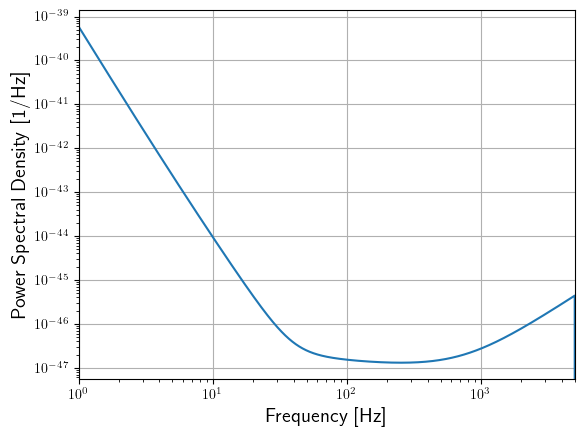

In [34]:
delta_f = 1.0 / 1000
flen = int(5000 / delta_f)
low_frequency_cutoff = 1

psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(flen, delta_f, low_frequency_cutoff)

plt.plot(psd.sample_frequencies, psd)

plt.xlabel("Frequency [Hz]", fontsize = "x-large")
plt.ylabel("Power Spectral Density [1/Hz]", fontsize = "x-large")
plt.xscale("log")
plt.yscale("log")
plt.xlim(xmin = low_frequency_cutoff, xmax = 5000)

plt.grid()
plt.gca().set_axisbelow(True)

plt.savefig("PSD of the Advanced LIGO Design.pdf", bbox_inches = "tight")
plt.show()

## Waveform Degeneracy up to the Mass Quadrupole

In [12]:
params_2B = [150e-13, 10, 8, 2e6, 30, 0]
print("Binary chirp mass in solar mass = {}".format(waveforms.CircularBinary(*params_2B).M_c/sol))

Binary chirp mass in solar mass = 7.776774233174123


/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:52: RuntimeWarning: invalid value encountered in power
  return (5**(3/8))/8 * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(-3/8)
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:56: RuntimeWarning: invalid value encountered in power
  return -(5**(-5/8)) * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(5/8)
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:195: RuntimeWarning: invalid value encountered in power
  return (5**(3/8))/8 * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(-3/8)
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:199: RuntimeWarning: invalid value encountered in power
  return -(5**(-5/8)) * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(5/8)


Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 2.8231080866430836e-11, m1 = 1.7999999999999998, m2 = 1.7999999999999998, m3 = 116.39999999999999, r = 2740065.1206373814, i = 30, phi = 3.7170795961392744

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 0.9631873402104029



(np.float64(0.32845418783682995), np.float64(125.47251810099907))

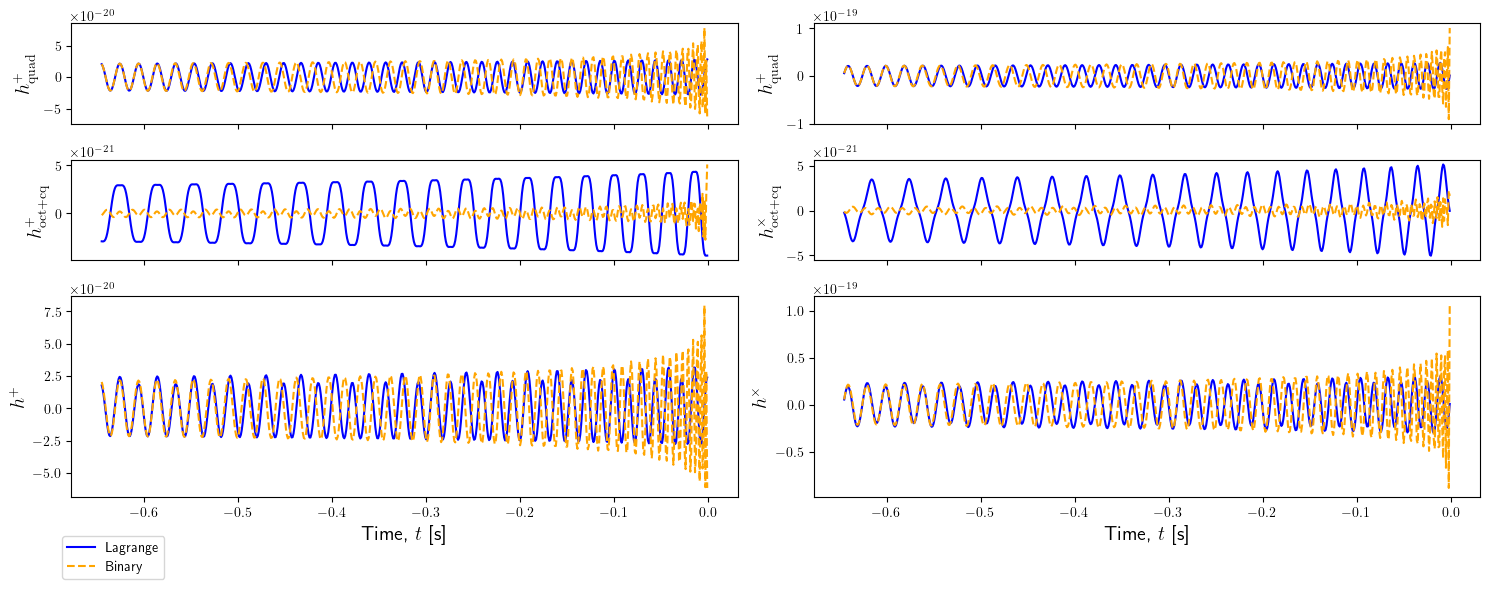

In [13]:
delta_t = 1/1000
t_max = 0.645

beta_1 = 0.015
M_3B = 120
i_3B = 30
quad_result = findQuadDegeneracy_plus(*params_2B[:5], M_3B, beta_1, i_3B, atol = 1e-22)
params_3B_quad1 = [quad_result[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result[1], i_3B, quad_result[2]]

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad1, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time_combined(params_2B, params_3B_quad1, t_max = t_max, delta_t = delta_t, radRxn = True,
                                     filename = "LaTeX Files/Figures/Quadrupole Degeneracy/Pub - MQ Degeneracy 1.pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_quad1).t_c))
print("")

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 3.0411009977866976e-11, m1 = 2.25, m2 = 2.25, m3 = 145.5, r = 3974454.8960382254, i = 30, phi = 4.824027157764506

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 0.6640397499996263



(np.float64(0.8384901547585671), np.float64(15.770620283691056))

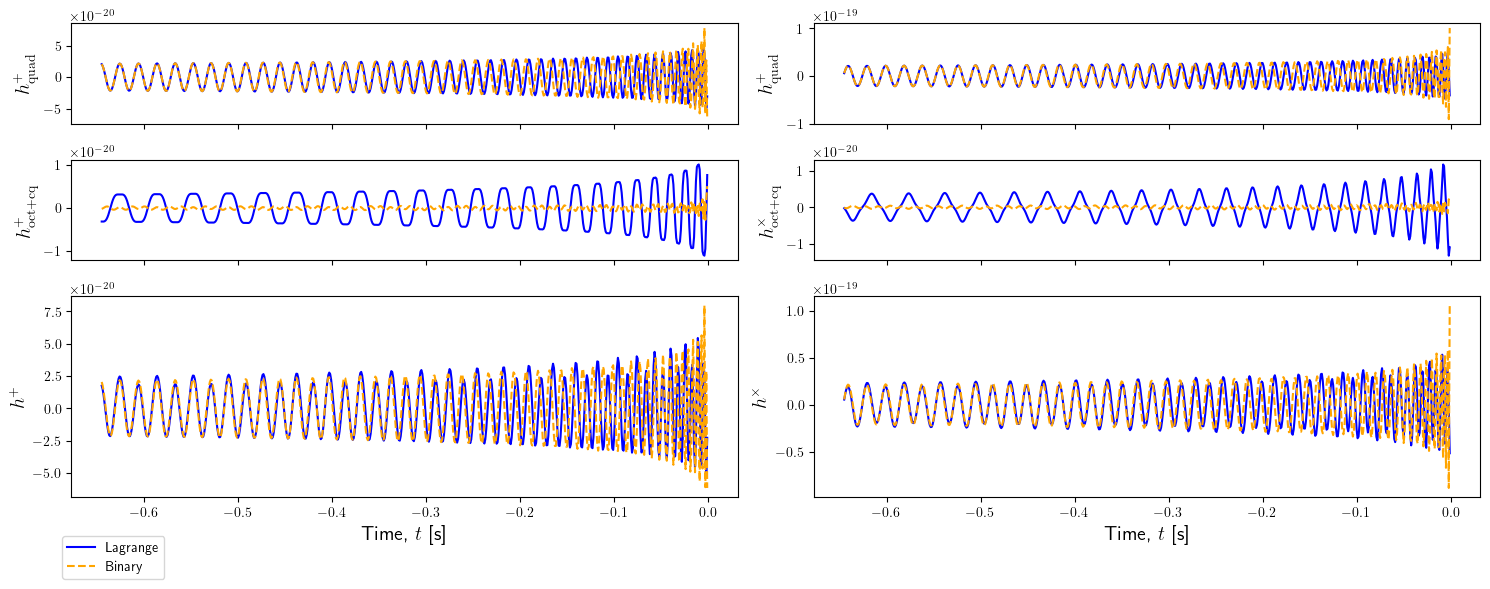

In [14]:
delta_t = 1/1000
t_max = 0.645

beta_1 = 0.015
M_3B = 150
i_3B = 30
quad_result = findQuadDegeneracy_plus(*params_2B[:5], M_3B, beta_1, i_3B, atol = 1e-22)
params_3B_quad2 = [quad_result[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result[1], i_3B, quad_result[2]]

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad2, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time_combined(params_2B, params_3B_quad2, t_max = t_max, delta_t = delta_t, radRxn = True,
                                     filename = "LaTeX Files/Figures/Quadrupole Degeneracy/Pub - MQ Degeneracy 2.pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_quad2).t_c))
print("")

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

We also perform the waveform match in the case where the binary and the Lagrange triple (with a total mass of 150 ${\mathrm{M}}_{\odot} \gg \mathcal{M}_{\mathrm{(2B)}} = 7.776$) have the same quadrupole waveforms and chirp mass. As a consequence of the latter, both waveforms have the same frequency sweep.

Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 3.0411009977866976e-11, m1 = 2.3231939027306483, m2 = 2.3231939027306483, m3 = 145.3536121945387, r = 4525962.497957064, i = 15, phi = 6.283185307179586

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 0.6446118194246188



(np.float64(0.9942865277550864), np.float64(-0.012484861568883404))

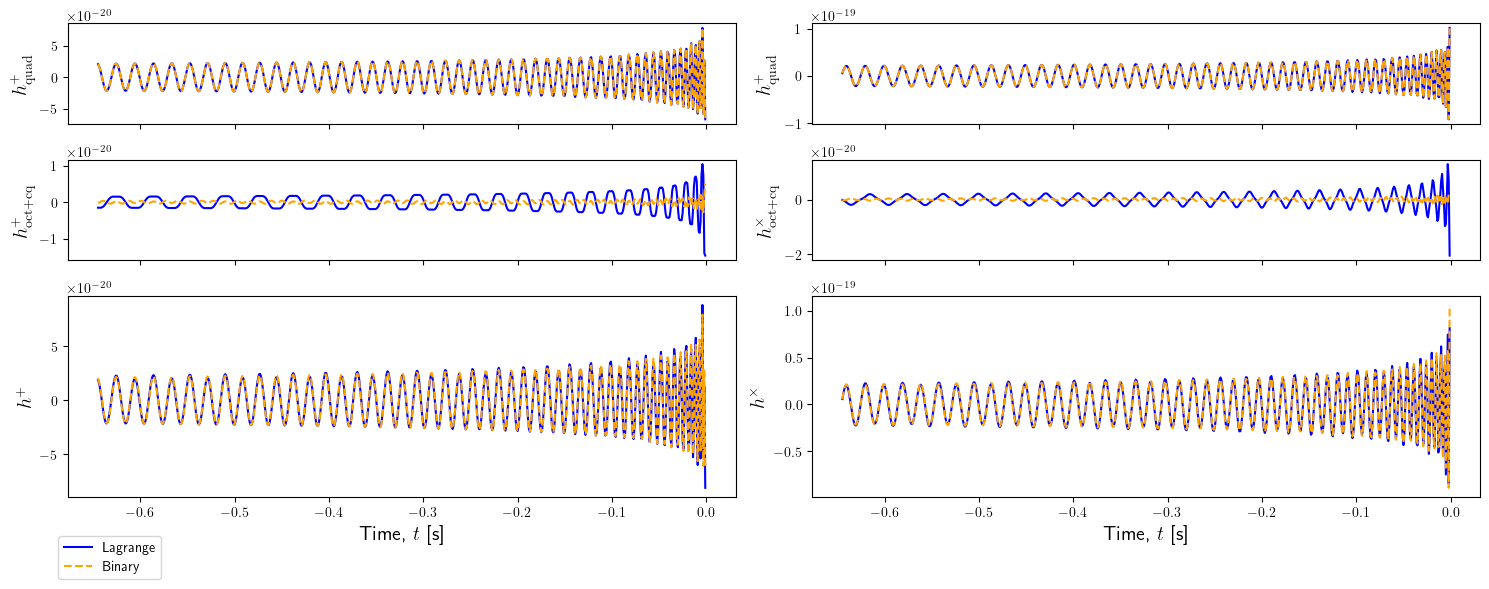

In [16]:
M_3B = 150
val = (waveforms.CircularBinary(*params_2B).M_c/sol)/M_3B

temp = poly.polyroots([-8*(val**5), 36*(val**5), -54*(val**5), 1 + 27*val**5, -18, 135, -540, 1215, -1458, 729])
temp = temp[np.isclose(temp.imag, 0)]
temp = temp[temp > 0]

beta_1 = np.real(np.min(temp))
i_3B = 15
quad_result = findQuadDegeneracy_plus(*params_2B[:5], M_3B, beta_1, i_3B, atol = 1e-22)
params_3B_quad3 = [quad_result[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result[1], i_3B, quad_result[2]]

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad3, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time_combined(params_2B, params_3B_quad3, t_max = t_max, delta_t = delta_t, radRxn = True,
                             filename = "LaTeX Files/Figures/Quadrupole Degeneracy/Pub - MQ Degeneracy 3.pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_quad3).t_c))
print()

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

A plot of the waveform match time series for the symmetric binary used above is shown below.

0.9942865277550864


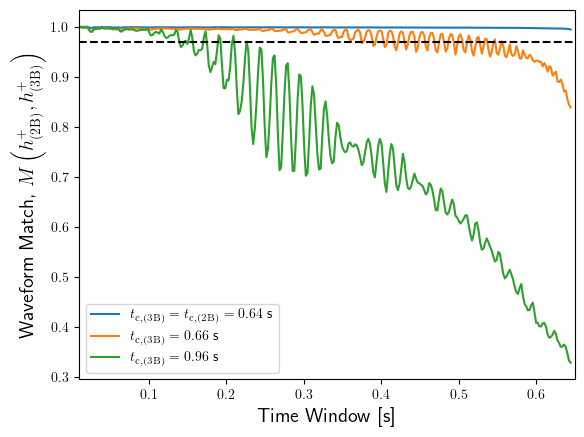

In [18]:
binary = waveforms.CircularBinary(*params_2B)
params_3B_quad = [params_3B_quad3, params_3B_quad2, params_3B_quad1]
markers = ["o", "d", "^", "X"]

t_window = np.linspace(0.01, binary.t_c, 300)

for i in range(len(params_3B_quad)):
    match_timeSeries = np.zeros(len(t_window))
    
    for j in range(len(t_window)):
        lagrange = waveforms.CircularLagrangeTriple(*params_3B_quad[i])
        
        hp_2B_windowed = waveforms.h_combined2B(*params_2B, t_max = t_window[j], delta_t = 1/1000)[0]
        hp_3B_windowed = waveforms.h_combined3B(*params_3B_quad[i], t_max = t_window[j], delta_t = 1/1000)[0]
        psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B_windowed) // 2 + 1, 1.0 / hp_2B_windowed.duration, 0)
        
        match_timeSeries[j] = pycbc.filter.match(hp_2B_windowed, hp_3B_windowed, psd = psd, low_frequency_cutoff = 0, subsample_interpolation = True)[0]

    if i == 0:
        #print(match_timeSeries)
        plt.plot(t_window, match_timeSeries, label = r"$t_{{\mathrm{{c,(3B)}}}} = t_{{\mathrm{{c,(2B)}}}} = {:.2f}$ s".format(lagrange.t_c))
        print(match_timeSeries[-1])
    else:
        plt.plot(t_window, match_timeSeries, label = r"$t_{{\mathrm{{c,(3B)}}}} = {:.2f}$ s".format(lagrange.t_c))

plt.legend()
plt.xlabel("Time Window [s]", fontsize = "x-large")
plt.ylabel(r"Waveform Match, $M\left(h^{+}_{\mathrm{(2B)}}, h^{+}_{\mathrm{(3B)}}\right)$", fontsize = "x-large")
plt.xlim(0.01, 0.65)
plt.axhline(0.97, 0, 1, ls = "--", color = "black")

plt.savefig("LaTeX Files/Figures/Tests with LIGO PSD/Match Time Series for MQ Plus Degeneracy.pdf",
            bbox_inches = "tight")
plt.show()

0.9950075928784274


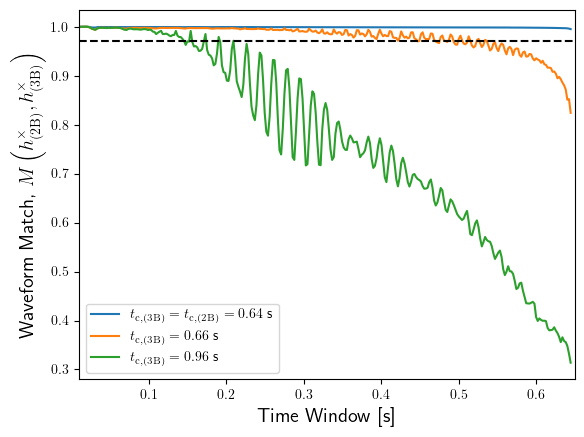

In [19]:
binary = waveforms.CircularBinary(*params_2B)
params_3B_quad = [params_3B_quad3, params_3B_quad2, params_3B_quad1]
markers = ["o", "d", "^", "X"]

t_window = np.linspace(0.01, binary.t_c, 300)

for i in range(len(params_3B_quad)):
    match_timeSeries_cross = np.zeros(len(t_window))
    
    for j in range(len(t_window)):
        lagrange = waveforms.CircularLagrangeTriple(*params_3B_quad[i])
        
        hc_2B_windowed = waveforms.h_combined2B(*params_2B, t_max = t_window[j], delta_t = 1/1000)[1]
        hc_3B_windowed = waveforms.h_combined3B(*params_3B_quad[i], t_max = t_window[j], delta_t = 1/1000)[1]
        psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hc_2B_windowed) // 2 + 1, 1.0 / hc_2B_windowed.duration, 0)
        
        match_timeSeries_cross[j] = pycbc.filter.match(hc_2B_windowed, hc_3B_windowed, psd = psd, low_frequency_cutoff = 0, subsample_interpolation = True)[0]

    if i == 0:
        #print(match_timeSeries_cross)
        plt.plot(t_window, match_timeSeries_cross, label = r"$t_{{\mathrm{{c,(3B)}}}} = t_{{\mathrm{{c,(2B)}}}} = {:.2f}$ s".format(lagrange.t_c))
        print(match_timeSeries_cross[-1])
    else:
        plt.plot(t_window, match_timeSeries_cross, label = r"$t_{{\mathrm{{c,(3B)}}}} = {:.2f}$ s".format(lagrange.t_c))

plt.legend()
plt.xlabel("Time Window [s]", fontsize = "x-large")
plt.ylabel(r"Waveform Match, $M\left(h^{\times}_{\mathrm{(2B)}}, h^{\times}_{\mathrm{(3B)}}\right)$", fontsize = "x-large")
plt.xlim(0.01, 0.65)
plt.axhline(0.97, 0, 1, ls = "--", color = "black")

plt.savefig("LaTeX Files/Figures/Tests with LIGO PSD/Match Time Series for MQ Cross Degeneracy.pdf",
            bbox_inches = "tight")
plt.show()

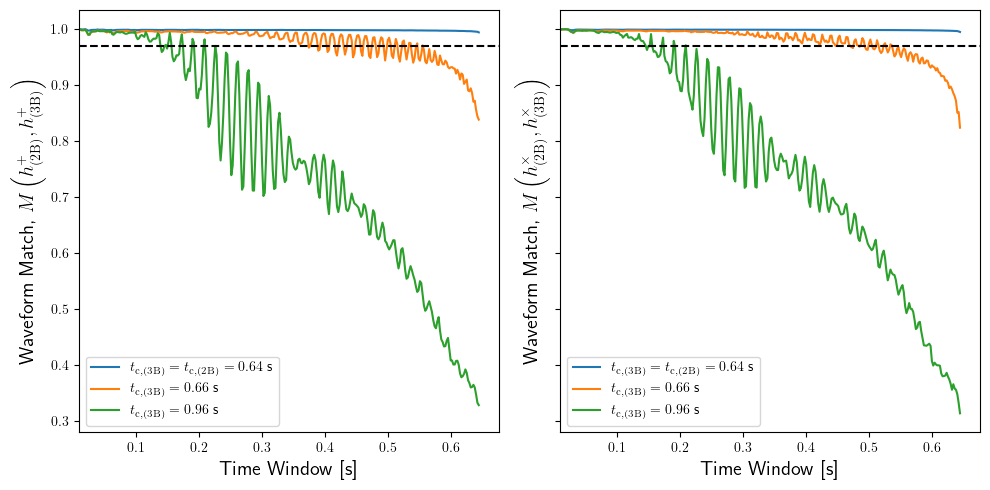

In [20]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, sharex = True, sharey = True, figsize = (10, 5))

binary = waveforms.CircularBinary(*params_2B)
params_3B_quad = [params_3B_quad3, params_3B_quad2, params_3B_quad1]
markers = ["o", "d", "^", "X"]

t_window = np.linspace(0.01, binary.t_c, 300)

for i in range(len(params_3B_quad)):
    match_timeSeries_plus = np.zeros(len(t_window))
    match_timeSeries_cross = np.zeros(len(t_window))
    
    for j in range(len(t_window)):
        lagrange = waveforms.CircularLagrangeTriple(*params_3B_quad[i])
        
        hp_2B_windowed = waveforms.h_combined2B(*params_2B, t_max = t_window[j], delta_t = 1/1000)[0]
        hp_3B_windowed = waveforms.h_combined3B(*params_3B_quad[i], t_max = t_window[j], delta_t = 1/1000)[0]
        psd_p = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B_windowed) // 2 + 1, 1.0 / hp_2B_windowed.duration, 0)
        
        hc_2B_windowed = waveforms.h_combined2B(*params_2B, t_max = t_window[j], delta_t = 1/1000)[1]
        hc_3B_windowed = waveforms.h_combined3B(*params_3B_quad[i], t_max = t_window[j], delta_t = 1/1000)[1]
        psd_c = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hc_2B_windowed) // 2 + 1, 1.0 / hc_2B_windowed.duration, 0)
        
        match_timeSeries_plus[j] = pycbc.filter.match(hp_2B_windowed, hp_3B_windowed, psd = psd_p, low_frequency_cutoff = 0, subsample_interpolation = True)[0]
        match_timeSeries_cross[j] = pycbc.filter.match(hc_2B_windowed, hc_3B_windowed, psd = psd_c, low_frequency_cutoff = 0, subsample_interpolation = True)[0]

    if i == 0:
        ax[0].plot(t_window, match_timeSeries_plus, label = r"$t_{{\mathrm{{c,(3B)}}}} = t_{{\mathrm{{c,(2B)}}}} = {:.2f}$ s".format(lagrange.t_c))
        ax[1].plot(t_window, match_timeSeries_cross, label = r"$t_{{\mathrm{{c,(3B)}}}} = t_{{\mathrm{{c,(2B)}}}} = {:.2f}$ s".format(lagrange.t_c))
    else:
        ax[0].plot(t_window, match_timeSeries_plus, label = r"$t_{{\mathrm{{c,(3B)}}}} = {:.2f}$ s".format(lagrange.t_c))
        ax[1].plot(t_window, match_timeSeries_cross, label = r"$t_{{\mathrm{{c,(3B)}}}} = {:.2f}$ s".format(lagrange.t_c))

ax[0].legend()
ax[0].set_xlabel("Time Window [s]", fontsize = "x-large")
ax[0].set_ylabel(r"Waveform Match, $M\left(h^{+}_{\mathrm{(2B)}}, h^{+}_{\mathrm{(3B)}}\right)$", fontsize = "x-large")
ax[0].axhline(0.97, 0, 1, ls = "--", color = "black")
ax[0].set_xlim(0.01)

ax[1].legend()
ax[1].set_xlabel("Time Window [s]", fontsize = "x-large")
ax[1].set_ylabel(r"Waveform Match, $M\left(h^{\times}_{\mathrm{(2B)}}, h^{\times}_{\mathrm{(3B)}}\right)$", fontsize = "x-large")
ax[1].axhline(0.97, 0, 1, ls = "--", color = "black")
ax[1].set_xlim(0.01)

plt.tight_layout()
plt.savefig("LaTeX Files/Figures/Tests with LIGO PSD/Match Time Series for MQ Degeneracy.pdf",
            bbox_inches = "tight")
plt.show()

We can also calculate the how the waveform match of degenerate systems up to the coalescence time evolve as the mass difference in the binary increases. We expect that as the mass difference in the binary grows larger, the waveform match decreases due to the increasing effect of the 0.5PN to the total waveform.

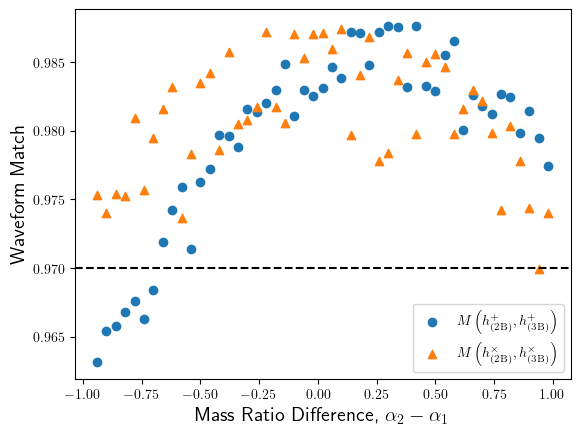

In [22]:
M_2B = 10
alpha2_vals = np.arange(0.99, 0.01, -0.02)

#free parameters of the Lagrange triple
M_3B = 150
i_3B = 30

match_massDiff_plus = np.zeros(len(alpha2_vals))
match_massDiff_cross = np.zeros(len(alpha2_vals))

for i in range(len(alpha2_vals)):
    params_2B_asymm_temp = [150e-13, M_2B*(1 - alpha2_vals[i]), alpha2_vals[i]*M_2B, 2e6, 30, 0]
    t_max = waveforms.CircularBinary(*params_2B_asymm_temp).t_c

    #find beta_1 so that the systems are degenerate up to the coalescence time
    val = (waveforms.CircularBinary(*params_2B_asymm_temp).M_c/sol)/M_3B
    root = poly.polyroots([-8*(val**5), 36*(val**5), -54*(val**5), 1 + 27*val**5, -18, 135, -540, 1215, -1458, 729])
    root = root[np.isclose(root.imag, 0)]
    root = root[root > 0]
    
    beta_1 = np.real(np.min(root))
    quad_result_temp = findQuadDegeneracy_plus(*params_2B_asymm_temp[:5], M_3B, beta_1, i_3B, atol = 1e-23)
    params_3B_quad_temp = [quad_result_temp[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result_temp[1], i_3B, quad_result_temp[2]]

    #calculate the waveform
    hp_2B, hc_2B = waveforms.h_combined2B(*params_2B_asymm_temp, t_max = t_max, delta_t = delta_t)
    hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad_temp, t_max = t_max, delta_t = delta_t)

    #calculate waveform match
    f_lower = 0
    psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)
    
    match_massDiff_plus[i] = pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)[0]
    match_massDiff_cross[i] = pycbc.filter.match(hc_2B, hc_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)[0]

plt.scatter(alpha2_vals - (1 - alpha2_vals), match_massDiff_plus, marker = "o",
            label = r"$M\left(h^{+}_{\mathrm{(2B)}}, h^{+}_{\mathrm{(3B)}}\right)$")
plt.scatter(alpha2_vals - (1 - alpha2_vals), match_massDiff_cross, marker = "^",
            label = r"$M\left(h^{\times}_{\mathrm{(2B)}}, h^{\times}_{\mathrm{(3B)}}\right)$")
plt.xlabel(r"Mass Ratio Difference, $\alpha_2 - \alpha_1$", fontsize = "x-large")
plt.ylabel(r"Waveform Match", fontsize = "x-large")
plt.axhline(0.97, 0, 1, ls = "--", color = "black")

plt.legend(loc = "lower right")
plt.savefig("LaTeX Files/Figures/Tests with LIGO PSD/Match vs Mass Ratio for MQ Degeneracy (M_2B = 10).pdf", bbox_inches = "tight")
plt.show()

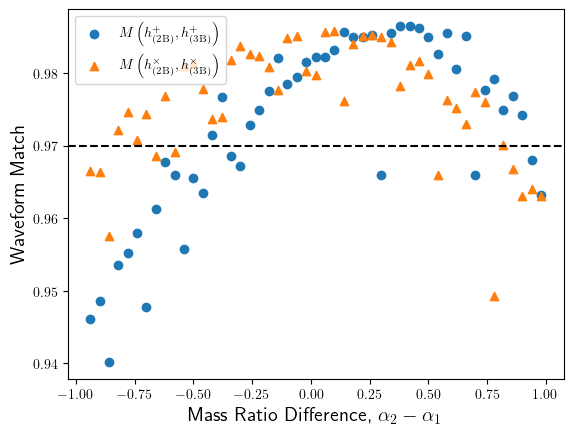

In [23]:
M_2B = 20
alpha2_vals = np.arange(0.99, 0.01, -0.02)

#free parameters of the Lagrange triple
M_3B = 150
i_3B = 30

match_massDiff_plus = np.zeros(len(alpha2_vals))
match_massDiff_cross = np.zeros(len(alpha2_vals))

for i in range(len(alpha2_vals)):
    params_2B_asymm_temp = [150e-13, M_2B*(1 - alpha2_vals[i]), alpha2_vals[i]*M_2B, 2e6, 30, 0]
    t_max = waveforms.CircularBinary(*params_2B_asymm_temp).t_c

    #find beta_1 so that the systems are degenerate up to the coalescence time
    val = (waveforms.CircularBinary(*params_2B_asymm_temp).M_c/sol)/M_3B
    root = poly.polyroots([-8*(val**5), 36*(val**5), -54*(val**5), 1 + 27*val**5, -18, 135, -540, 1215, -1458, 729])
    root = root[np.isclose(root.imag, 0)]
    root = root[root > 0]
    
    beta_1 = np.real(np.min(root))
    quad_result_temp = findQuadDegeneracy_plus(*params_2B_asymm_temp[:5], M_3B, beta_1, i_3B, atol = 1e-23)
    params_3B_quad_temp = [quad_result_temp[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result_temp[1], i_3B, quad_result_temp[2]]

    #calculate the waveform
    hp_2B, hc_2B = waveforms.h_combined2B(*params_2B_asymm_temp, t_max = t_max, delta_t = delta_t)
    hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad_temp, t_max = t_max, delta_t = delta_t)

    #calculate waveform match
    f_lower = 0
    psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)
    
    match_massDiff_plus[i] = pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)[0]
    match_massDiff_cross[i] = pycbc.filter.match(hc_2B, hc_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)[0]

plt.scatter(alpha2_vals - (1 - alpha2_vals), match_massDiff_plus, marker = "o",
            label = r"$M\left(h^{+}_{\mathrm{(2B)}}, h^{+}_{\mathrm{(3B)}}\right)$")
plt.scatter(alpha2_vals - (1 - alpha2_vals), match_massDiff_cross, marker = "^",
            label = r"$M\left(h^{\times}_{\mathrm{(2B)}}, h^{\times}_{\mathrm{(3B)}}\right)$")
plt.xlabel(r"Mass Ratio Difference, $\alpha_2 - \alpha_1$", fontsize = "x-large")
plt.ylabel(r"Waveform Match", fontsize = "x-large")
plt.axhline(0.97, 0, 1, ls = "--", color = "black")

plt.legend(loc = "upper left")
plt.savefig("LaTeX Files/Figures/Tests with LIGO PSD/Match vs Mass Ratio for MQ Degeneracy (M_2B = 20).pdf", bbox_inches = "tight")
plt.show()

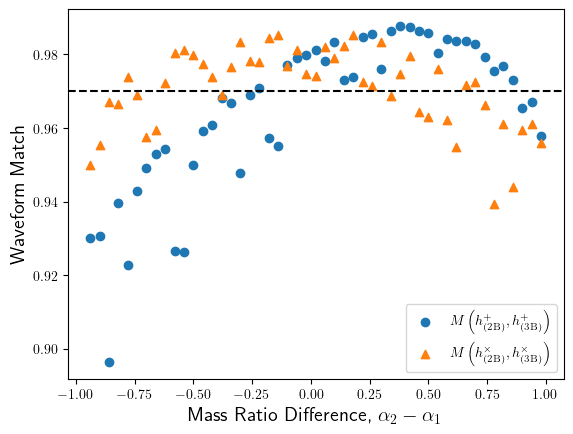

In [24]:
M_2B = 30
alpha2_vals = np.arange(0.99, 0.01, -0.02)

#free parameters of the Lagrange triple
M_3B = 150
i_3B = 30

match_massDiff_plus = np.zeros(len(alpha2_vals))
match_massDiff_cross = np.zeros(len(alpha2_vals))

for i in range(len(alpha2_vals)):
    params_2B_asymm_temp = [150e-13, M_2B*(1 - alpha2_vals[i]), alpha2_vals[i]*M_2B, 2e6, 30, 0]
    t_max = waveforms.CircularBinary(*params_2B_asymm_temp).t_c

    #find beta_1 so that the systems are degenerate up to the coalescence time
    val = (waveforms.CircularBinary(*params_2B_asymm_temp).M_c/sol)/M_3B
    root = poly.polyroots([-8*(val**5), 36*(val**5), -54*(val**5), 1 + 27*val**5, -18, 135, -540, 1215, -1458, 729])
    root = root[np.isclose(root.imag, 0)]
    root = root[root > 0]
    
    beta_1 = np.real(np.min(root))
    quad_result_temp = findQuadDegeneracy_plus(*params_2B_asymm_temp[:5], M_3B, beta_1, i_3B, atol = 1e-23)
    params_3B_quad_temp = [quad_result_temp[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result_temp[1], i_3B, quad_result_temp[2]]

    #calculate the waveform
    hp_2B, hc_2B = waveforms.h_combined2B(*params_2B_asymm_temp, t_max = t_max, delta_t = delta_t)
    hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad_temp, t_max = t_max, delta_t = delta_t)

    #calculate waveform match
    f_lower = 0
    psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)
    
    match_massDiff_plus[i] = pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)[0]
    match_massDiff_cross[i] = pycbc.filter.match(hc_2B, hc_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)[0]

plt.scatter(alpha2_vals - (1 - alpha2_vals), match_massDiff_plus, marker = "o",
            label = r"$M\left(h^{+}_{\mathrm{(2B)}}, h^{+}_{\mathrm{(3B)}}\right)$")
plt.scatter(alpha2_vals - (1 - alpha2_vals), match_massDiff_cross, marker = "^",
            label = r"$M\left(h^{\times}_{\mathrm{(2B)}}, h^{\times}_{\mathrm{(3B)}}\right)$")
plt.xlabel(r"Mass Ratio Difference, $\alpha_2 - \alpha_1$", fontsize = "x-large")
plt.ylabel(r"Waveform Match", fontsize = "x-large")
plt.axhline(0.97, 0, 1, ls = "--", color = "black")

plt.legend(loc = "lower right")
plt.savefig("LaTeX Files/Figures/Tests with LIGO PSD/Match vs Mass Ratio for MQ Degeneracy (M_2B = 30).pdf", bbox_inches = "tight")
plt.show()

## Waveform Degeneracy up to the 0.5PN Order

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_63831/3441334345.py:61: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_63831/3441334345.py:64: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_63831/3441334345.py:64: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


Min beta_1 for true degeneracy = 0.15909231818463634
Max beta_1 for true degeneracy = 0.20114840229680458
Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 1.4433756729740707e-12, m1 = 0.002672917912914973, m2 = 0.002672917912914973, m3 = 0.010691671651659894, r = 5.5685789852396175, i = 29.999999999999996, phi = 4.572448166486045

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 694552.5827683469



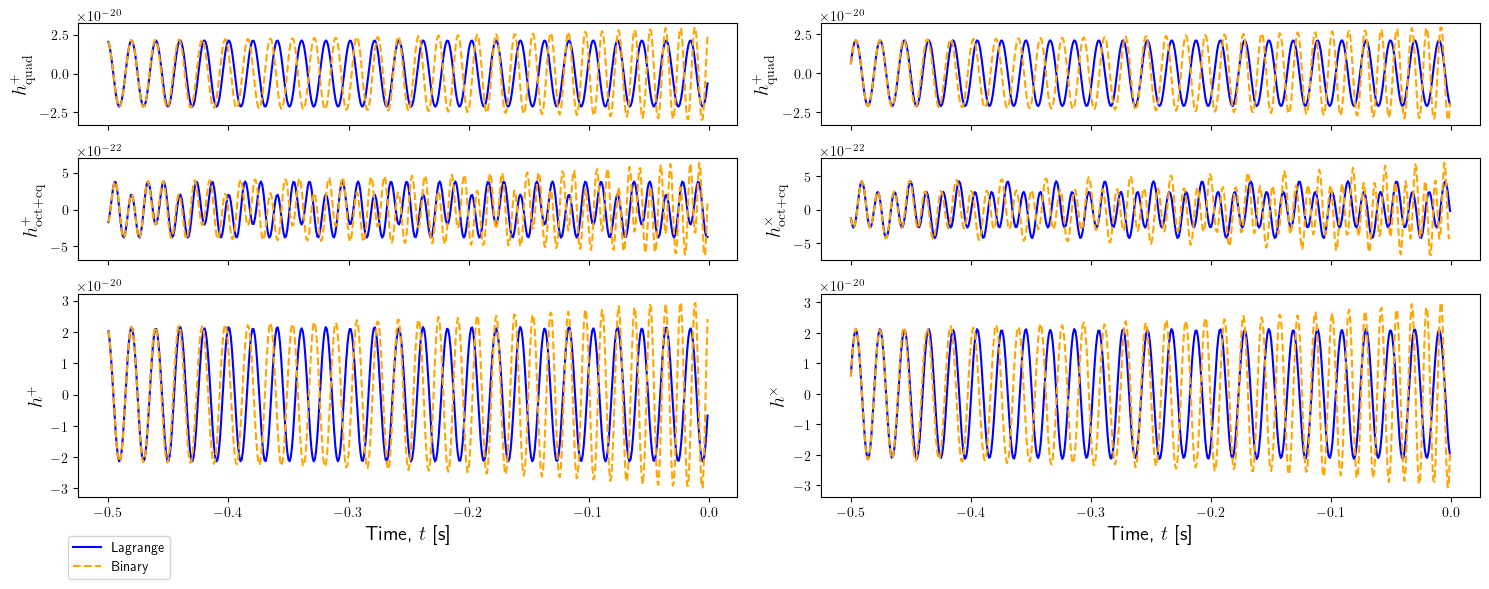

In [26]:
delta_t = 1/1000
t_max = 0.5

params_3B_oct1 = findOctDegeneracy_plus(params_2B, 1/6)

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_oct1, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time_combined(params_2B, params_3B_oct1, t_max = t_max, delta_t = delta_t, radRxn = True,
                            filename = "LaTeX Files/Figures/0.5PN Degeneracy/Pub - 0.5PN Degeneracy 1.pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_oct1).t_c))
print("")

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_60581/3441334345.py:61: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_60581/3441334345.py:64: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_60581/3441334345.py:64: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


Min beta_1 for true degeneracy = 0.15909231818463634
Max beta_1 for true degeneracy = 0.20114840229680458
Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 1.4433756729740707e-12, m1 = 0.002672917912914973, m2 = 0.002672917912914973, m3 = 0.010691671651659894, r = 5.5685789852396175, i = 29.999999999999996, phi = 4.572448166486045

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 694552.5827683469

[1.0566148e-22 3.1698444e-22]
[1.0566148e-22 3.1698444e-22]
[9.40395481e-38 3.29138418e-37]


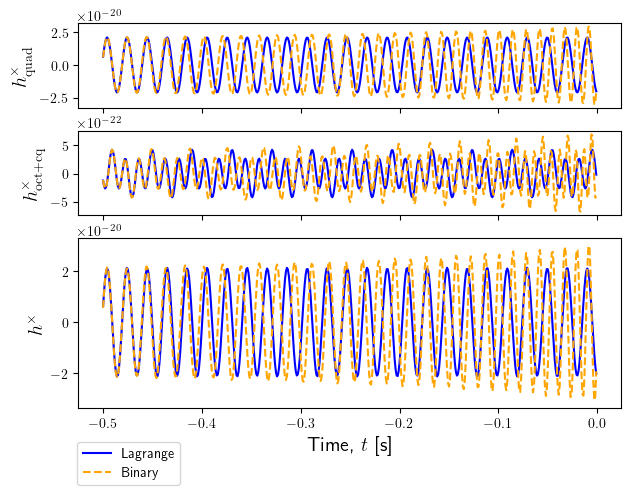

In [240]:
delta_t = 1/1000
t_max = 0.5

params_3B_oct1 = findOctDegeneracy_plus(params_2B, 1/6)

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_oct1, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B, params_3B_oct1, t_max = t_max, delta_t = delta_t, radRxn = True, pol = "cross",
                            filename = "LaTeX Files/Figures/0.5PN Degeneracy/Pub - 0.5PN Cross Degeneracy 2.pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_oct1).t_c))
print("")

print(waveforms.CircularBinary(*params_2B).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))
print(waveforms.CircularLagrangeTriple(*params_3B_oct1).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))
print(waveforms.CircularBinary(*params_2B).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross") - waveforms.CircularLagrangeTriple(*params_3B_oct1).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))

In [25]:
for beta_1 in np.linspace(0.15912194481944822, 0.1591219536000439, 100000)[50000:60000]:
    print(beta_1, (find_M_3B(*params_2B, beta_1)/sol)*((beta_1*(1 - 3*beta_1)**2)/(2 - 3*beta_1))**(3/5))

0.15912194920978998 7.7768882353642095
0.15912194920987777 7.7768882023546935
0.15912194920996559 7.776888169345176
0.1591219492100534 7.776888136335652
0.1591219492101412 7.776888103330771
0.159121949210229 7.776888070316623
0.1591219492103168 7.77688803732563
0.15912194921040462 7.776888004311479
0.1591219492104924 7.776887971306596
0.15912194921058023 7.776887938310967
0.15912194921066805 7.776887905292201
0.15912194921075584 7.7768878722873085
0.15912194921084366 7.776887839270849
0.15912194921093145 7.776887806265965
0.15912194921101927 7.776887773261076
0.15912194921110706 7.77688774026082
0.15912194921119488 7.776887707255941
0.1591219492112827 7.776887674237163
0.1591219492113705 7.776887641241539
0.1591219492114583 7.776887608236647
0.1591219492115461 7.77688757523177
0.15912194921163392 7.776887542217627
0.1591219492117217 7.776887509217374
0.15912194921180953 7.776887476203236
0.15912194921189735 7.7768874431937185
0.15912194921198514 7.776887410198108
0.15912194921207296 7.

In [26]:
for beta_1 in np.linspace(0.1591219495130748, 0.15912194951289915, 100000)[1000:1500]:
    print(beta_1, (find_M_3B(*params_2B, beta_1)/sol)*((beta_1*(1 - 3*beta_1)**2)/(2 - 3*beta_1))**(3/5))

0.15912194951307304 7.776774233119908
0.15912194951307304 7.776774233119908
0.15912194951307304 7.776774233119908
0.15912194951307304 7.776774233119908
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.15912194951307299 7.776774233133802
0.15912194951307299 7.776774233133802
0.15912194951307299 7.776774233133802
0.15912194951307299 7.776774233133802
0.15912194951307299 7.776774233133802
0.15912194951307299 7.776774233133802
0.15912194951307299 7.776774233133802
0.1591

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_60581/3441334345.py:61: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_60581/3441334345.py:64: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_60581/3441334345.py:64: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


Min beta_1 for true degeneracy = 0.15909231818463634
Max beta_1 for true degeneracy = 0.20114840229680458
Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 2.309373805332004e-11, m1 = 10.452291790150664, m2 = 10.452291790150664, m3 = 44.78271991324934, r = 6655437.262202962, i = 1.917277536430065, phi = 3.1573163405446967

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 0.644611819425072



(np.float64(nan), np.float64(nan))

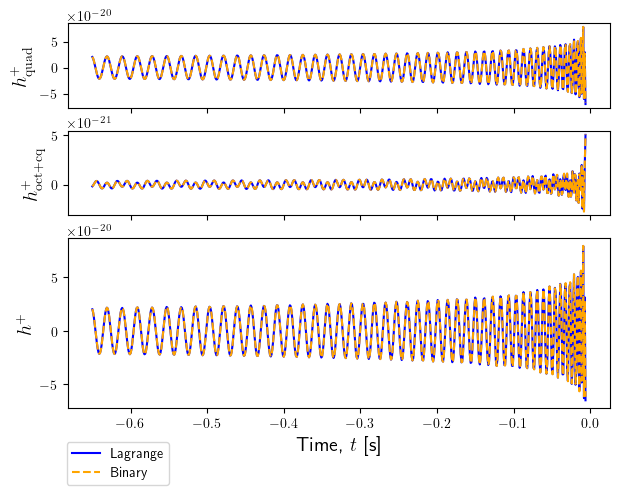

In [224]:
delta_t = 1/1000
t_max = 0.65

params_3B_oct1 = findOctDegeneracy(params_2B, 0.15912194951307287)

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_oct1, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B, params_3B_oct1, t_max = t_max, delta_t = delta_t, radRxn = True,
                            filename = "LaTeX Files/Figures/0.5PN Degeneracy/Pub - 0.5PN Plus Degeneracy 2.pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_oct1).t_c))
print("")

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

Both actual and predicted relative reductions in the sum of squares
  are at most 0.000000
Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 2.2038643766661088e-11, m1 = 9.41970424330016, m2 = 9.41970424330016, m3 = 38.249708139461255, r = 5332841.058608916, i = 1.9010546131127184, phi = 5.572474656817931

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 0.8314669877874763

[1.0566148e-22 3.1698444e-22]
[1.07574789e-22 3.16333786e-22]
[-1.91330921e-24  6.50653909e-25]


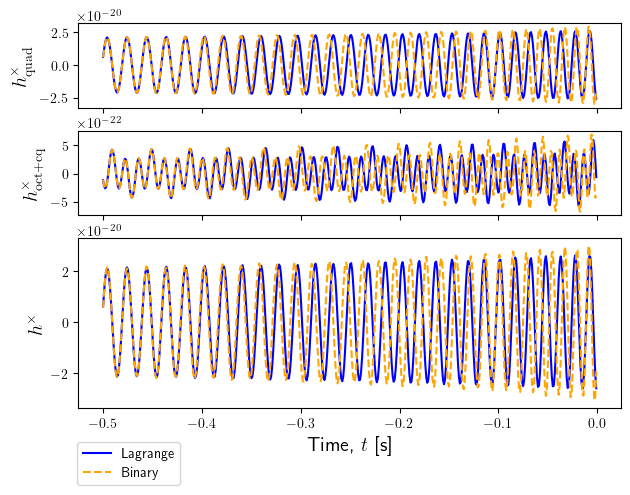

In [112]:
delta_t = 1/1000
t_max = 0.5
params_3B_oct_cross1 = findOctDegeneracy_cross([4e6, 50, 2], *params_2B, beta_1 = 0.165, root_tol = 1e-30, atol = 1e-23)

waveforms.plot_waveform_time(params_2B, params_3B_oct_cross1, t_max = t_max, delta_t = delta_t, radRxn = True, pol = "cross",
                             size = "vertical",
                            filename = "LaTeX Files/Figures/0.5PN Degeneracy/Pub - 0.5PN Cross Degeneracy 1.pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_oct_cross1).t_c))
print("")

print(waveforms.CircularBinary(*params_2B).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))
print(waveforms.CircularLagrangeTriple(*params_3B_oct_cross1).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))
print(waveforms.CircularBinary(*params_2B).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross") - waveforms.CircularLagrangeTriple(*params_3B_oct_cross1).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_60581/3441334345.py:163: RuntimeWarning: invalid value encountered in scalar power
  eq1 = binary.h_quad(1, ampOnly = True, pol = "cross") - 4*((const.G*M_3B/(const.c**2))**(5/3))*((w_2B/const.c)**(2/3))*b1*np.abs(3*b1 - 1)*np.cos(i_3B)/r_3B


Both actual and predicted relative reductions in the sum of squares
  are at most 0.000000
Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 1.8629532364910174e-11, m1 = 5.517274234206001, m2 = 5.517274234206001, m3 = 23.448415495375503, r = 2297575.4406276867, i = 2.337122256515875, phi = 0

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 1.8923727567618707

[1.0566148e-22 3.1698444e-22]
[1.13450859e-22 3.14171609e-22]
[-7.78937898e-24  2.81283049e-24]


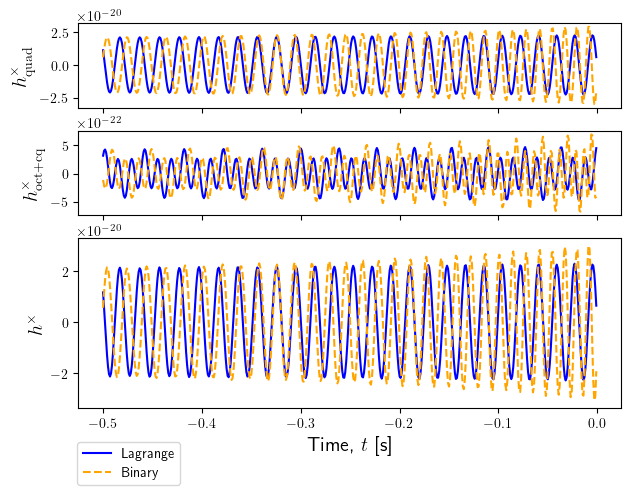

In [218]:
delta_t = 1/1000
t_max = 0.5
params_3B_oct_cross1 = findOctDegeneracy_cross([2.3e6, 50, 1.93], *params_2B, beta_1 = 0.16, root_tol = 1e-30, atol = 1e-24)

waveforms.plot_waveform_time(params_2B, params_3B_oct_cross1, t_max = t_max, delta_t = delta_t, radRxn = True, pol = "cross",
                             size = "vertical",
                            filename = "LaTeX Files/Figures/0.5PN Degeneracy/Pub - 0.5PN Cross Degeneracy 2.pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_oct_cross1).t_c))
print("")

print(waveforms.CircularBinary(*params_2B).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))
print(waveforms.CircularLagrangeTriple(*params_3B_oct_cross1).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))
print(waveforms.CircularBinary(*params_2B).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross") - waveforms.CircularLagrangeTriple(*params_3B_oct_cross1).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))

# 4: Signal-to-Noise Ratio (SNR) Calculations

In reality, the GW signal is buried under colored noise, i.e., background noise that is frequency-dependent. Using the LIGO noise curve, we can generate a colored noise that covers the signal we generated earlier. We follow this __[notebook](https://github.com/gw-odw/odw-2023/blob/main/Tutorials/Day_2/Tuto_2.1_Matched_filtering_introduction.ipynb)__ for generating the colored noise and whitening the noise.

In [ ]:
#generate the waveform
delta_t = 1/1000
t_max = 12

params_2B = [1e-11, 2.3, 1.6, 5e9, 75, 0]

hp_2B, hc_2B = h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)

# The color of the noise matches a PSD which you provide:
# Generate a PSD matching Advanced LIGO's zero-detuned--high-power noise curve
sample_rate = int(1/delta_t)
data_length = len(hp_2B.sample_times)
f_low = 10
f_len = int(sample_rate / (2 * hp_2B.delta_f)) + 1
psd = pycbc.psd.aLIGOZeroDetHighPower(f_len, hp_2B.delta_f, f_low)

noise = pycbc.noise.noise_from_psd(data_length*sample_rate, delta_t, psd, seed = 127)

# Estimate the amplitude spectral density (ASD = sqrt(PSD)) for the noisy data 
# using the "welch" method. We'll choose 4 seconds PSD samples that are overlapped 50%
seg_len = int(4/delta_t)
seg_stride = int(seg_len/2)
estimated_psd = pycbc.psd.welch(noise, seg_len = seg_len, seg_stride = seg_stride)

plt.loglog(estimated_psd.sample_frequencies, estimated_psd, label = "Estimate")
plt.loglog(psd.sample_frequencies, psd, label = "Known PSD")
plt.xlim(xmin=f_low, xmax=512)
plt.ylim(1e-47, 1e-45)
plt.xlabel("Frequency [Hz]", fontsize = "x-large")
plt.ylabel("Noise spectral density", fontsize = "x-large")
plt.legend()
plt.grid()
plt.show()

#add the signal to the noise to generate an artificial strain detection
waveform_start = np.random.randint(0, len(noise) - len(hp_2B))
data = noise[waveform_start:waveform_start + len(hp_2B)] + hp_2B.numpy()

plt.plot(hp_2B.sample_times, data)
plt.xlabel(r"Observer time, $t$ [s]", fontsize = "x-large")
plt.ylabel(r"Strain, $s(t)$", fontsize = "x-large")
plt.show()
plt.show()

We now whiten the data in the frequency domain.

In [ ]:
snr = pycbc.filter.matched_filter(hp_3B, data, psd = psd, low_frequency_cutoff = 10)

plt.plot(snr.sample_times, abs(snr))
plt.xlabel("Time (s)")
plt.ylabel("Signal-to-noise")
plt.show()